Dataset successfully loaded into the notebook!
Dataset Shape: 506 rows, 14 columns

--- First 5 Rows of the Dataset ---


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2



--- Missing Values & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


None


--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


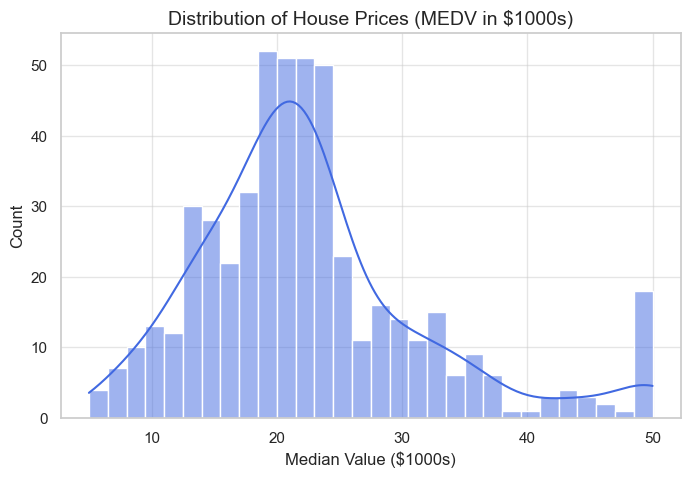

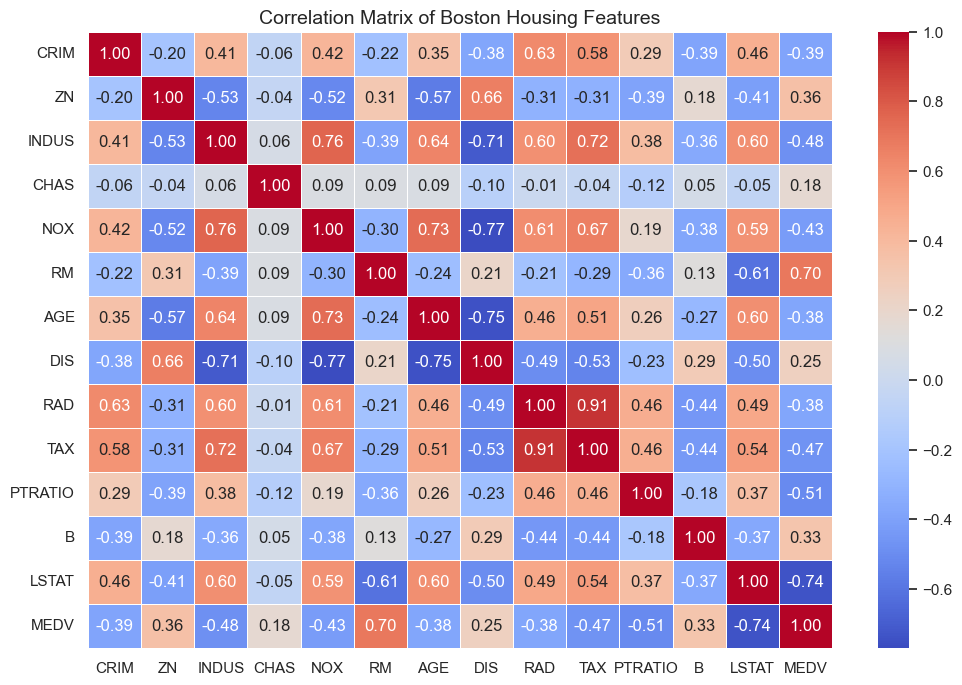

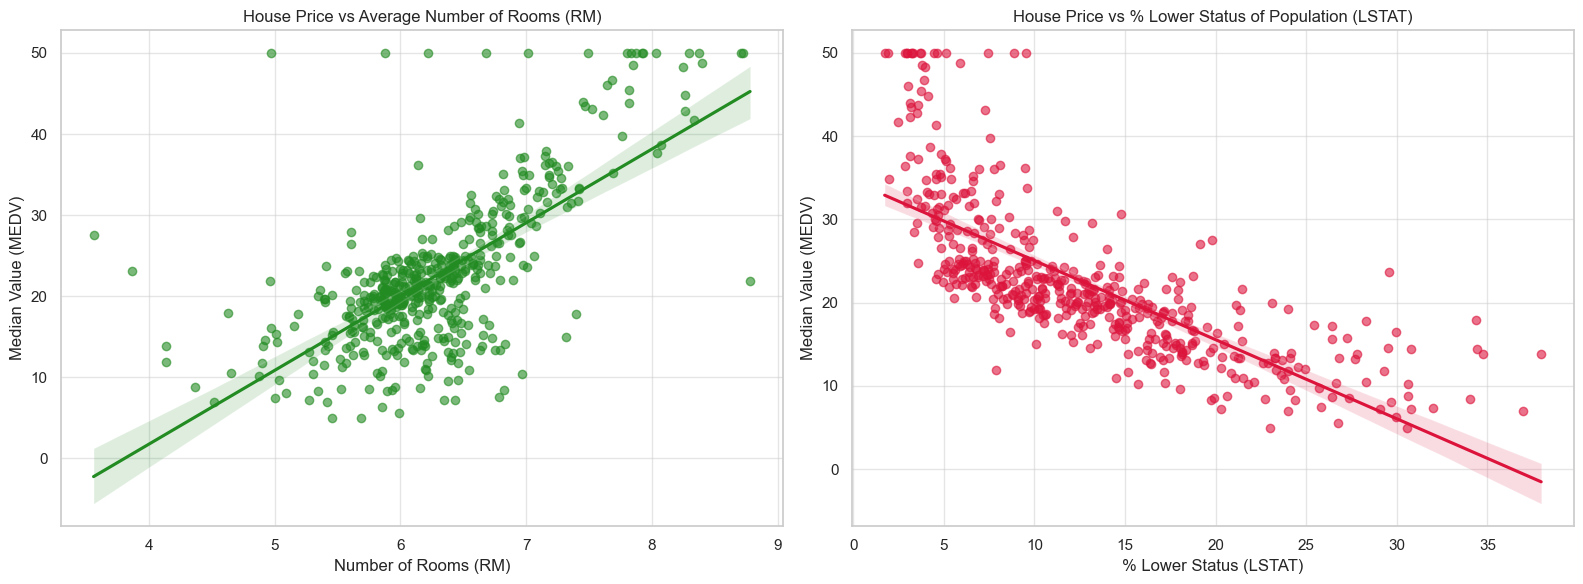

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for clean visuals
sns.set_theme(style="whitegrid")
%matplotlib inline

# =====================================================================
# 1. Load the Local Dataset
# =====================================================================
data_path = "../data/raw/boston_raw.csv"

if not os.path.exists(data_path):
    print(f"Error: Data file not found at {data_path}!")
    print("Please run 'python src/data_loader.py' in your terminal first to download the data.")
else:
    df = pd.read_csv(data_path)
    print("Dataset successfully loaded into the notebook!")
    print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# =====================================================================
# 2. Basic Data Inspection
# =====================================================================
print("--- First 5 Rows of the Dataset ---")
display(df.head())

print("\n--- Missing Values & Data Types ---")
display(df.info())

print("\n--- Summary Statistics ---")
display(df.describe().T)

# =====================================================================
# 3. Visualizing Target Variable (MEDV - House Price) Distribution
# =====================================================================
plt.figure(figsize=(8, 5))
sns.histplot(df['MEDV'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of House Prices (MEDV in $1000s)', fontsize=14)
plt.xlabel('Median Value ($1000s)')
plt.ylabel('Count')
plt.show()

# =====================================================================
# 4. Correlation Matrix (Feature Relationships)
# =====================================================================
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Boston Housing Features', fontsize=14)
plt.show()

# =====================================================================
# 5. Key Feature Analysis (Scatter Plots)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Room count vs Price (Positive Correlation)
sns.regplot(data=df, x='RM', y='MEDV', ax=axes[0], color='forestgreen', scatter_kws={'alpha':0.6})
axes[0].set_title('House Price vs Average Number of Rooms (RM)', fontsize=12)
axes[0].set_xlabel('Number of Rooms (RM)')
axes[0].set_ylabel('Median Value (MEDV)')

# Lower status population % vs Price (Negative Correlation)
sns.regplot(data=df, x='LSTAT', y='MEDV', ax=axes[1], color='crimson', scatter_kws={'alpha':0.6})
axes[1].set_title('House Price vs % Lower Status of Population (LSTAT)', fontsize=12)
axes[1].set_xlabel('% Lower Status (LSTAT)')
axes[1].set_ylabel('Median Value (MEDV)')

plt.tight_layout()
plt.show()
